# 🌲 Random Forest para Signature Detection

Este notebook entrena un **Random Forest** para clasificación multiclase de ataques de red.

## Características:
- **22 features** seleccionadas para SD
- **15 clases** (0=Benigno, 1-14=Tipos de ataque)
- Datos **balanceados** con SMOTE
- **GridSearch** para optimización de hiperparámetros

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Features del modelo SD (22 features) - orden canonico
SD_FEATURES = [
    'Dst Port', 'xhr', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd IAT Tot', 'Bwd IAT Mean',
    'Bwd IAT Max', 'Fwd PSH Flags', 'Fwd Pkts/s', 'Bwd Pkts/s', 'RST Flag Cnt',
    'PSH Flag Cnt', 'ACK Flag Cnt', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Seg Size Min', 'Idle Min', 'Protocol_6', 'Protocol_17'
]

print(f"✅ Features SD definidas: {len(SD_FEATURES)}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/data_ml1/preprocessed-sd.csv'

## 1️⃣ Configuración

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import time

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

# Montar Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Librerías cargadas")

Mounted at /content/drive
✅ Librerías cargadas


In [ ]:
# ⚙️ CONFIGURACIÓN DE RUTAS
DATA_DIR = '/content/drive/MyDrive/data_ml1/signature_detection'
MODEL_DIR = '/content/drive/MyDrive/data_ml1/models'

# Crear directorio de modelos si no existe
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

# Rutas de datos
TRAIN_PATH = os.path.join(DATA_DIR, 'sd_train_balanced.csv')
TEST_PATH = os.path.join(DATA_DIR, 'sd_test.csv')

print(f"📂 Train: {TRAIN_PATH}")
print(f"📂 Test: {TEST_PATH}")

📂 Train: /content/drive/MyDrive/data_ml1/signature_detection/sd_train_balanced.csv
📂 Test: /content/drive/MyDrive/data_ml1/signature_detection/sd_test.csv


In [ ]:
# Mapeo de clases
CLASS_NAMES = {
    0: "Benign",
    1: "DoS-SlowHTTPTest",
    2: "DoS-Hulk",
    3: "DoS-GoldenEye",
    4: "DoS-Slowloris",
    5: "DDoS-LOIC-UDP",
    6: "DDoS-HOIC",
    7: "DDoS-LOIC-HTTP",
    8: "Bot",
    9: "FTP-BruteForce",
    10: "SSH-Bruteforce",
    11: "Infilteration",
    12: "SQL Injection",
    13: "Brute Force-Web",
    14: "Brute Force-XSS"
}

print("📋 Clases:")
for k, v in CLASS_NAMES.items():
    print(f"   {k}: {v}")

📋 Clases:
   0: Benign
   1: DoS-SlowHTTPTest
   2: DoS-Hulk
   3: DoS-GoldenEye
   4: DoS-Slowloris
   5: DDoS-LOIC-UDP
   6: DDoS-HOIC
   7: DDoS-LOIC-HTTP
   8: Bot
   9: FTP-BruteForce
   10: SSH-Bruteforce
   11: Infilteration
   12: SQL Injection
   13: Brute Force-Web
   14: Brute Force-XSS


## 2️⃣ Cargar datos

In [ ]:
# Cargar datos
print("📂 Cargando datos de entrenamiento...")
df_train = pd.read_csv(TRAIN_PATH)
print(f"   ✓ Train: {df_train.shape[0]:,} filas x {df_train.shape[1]} columnas")

print("📂 Cargando datos de test...")
df_test = pd.read_csv(TEST_PATH)
print(f"   ✓ Test: {df_test.shape[0]:,} filas x {df_test.shape[1]} columnas")

📂 Cargando datos de entrenamiento...
   ✓ Train: 1,845,177 filas x 23 columnas
📂 Cargando datos de test...
   ✓ Test: 3,227,437 filas x 23 columnas


In [ ]:
# Separar features y labels (orden canonico)
FEATURES = SD_FEATURES
print(f"📋 Features ({len(FEATURES)}): {FEATURES}")

X_train = df_train[FEATURES].values
y_train = df_train['Label'].values

X_test = df_test[FEATURES].values
y_test = df_test['Label'].values

print(f"
📊 X_train shape: {X_train.shape}")
print(f"📊 X_test shape: {X_test.shape}")

# Escalado consistente (fit en train, transform en train/test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Guardar scaler junto con el modelo
scaler_path = os.path.join(MODEL_DIR, 'sd_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler guardado: {scaler_path}")


📋 Features (22): ['Dst Port', 'xhr', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Max', 'Fwd PSH Flags', 'Fwd Pkts/s', 'Bwd Pkts/s', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Seg Size Min', 'Idle Min', 'Protocol_6', 'Protocol_17']

📊 X_train shape: (1845177, 22)
📊 X_test shape: (3227437, 22)


In [ ]:
# Verificar distribución
print("📊 Distribución en Train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Clase {int(u)} ({CLASS_NAMES[int(u)]}): {c:,}")

📊 Distribución en Train:
   Clase 0 (Benign): 200,000
   Clase 1 (DoS-SlowHTTPTest): 111,912
   Clase 2 (DoS-Hulk): 200,000
   Clase 3 (DoS-GoldenEye): 50,000
   Clase 4 (DoS-Slowloris): 50,000
   Clase 5 (DDoS-LOIC-UDP): 50,000
   Clase 6 (DDoS-HOIC): 200,000
   Clase 7 (DDoS-LOIC-HTTP): 200,000
   Clase 8 (Bot): 200,000
   Clase 9 (FTP-BruteForce): 154,683
   Clase 10 (SSH-Bruteforce): 150,071
   Clase 11 (Infilteration): 128,511
   Clase 12 (SQL Injection): 50,000
   Clase 13 (Brute Force-Web): 50,000
   Clase 14 (Brute Force-XSS): 50,000


## 3️⃣ Entrenamiento inicial (baseline)

In [ ]:
%%time
# Modelo baseline
print("🚀 Entrenando modelo baseline...")

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_baseline.fit(X_train, y_train)
print("\n✅ Modelo baseline entrenado!")

🚀 Entrenando modelo baseline...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   14.0s



✅ Modelo baseline entrenado!
CPU times: user 4min 45s, sys: 1.21 s, total: 4min 46s
Wall time: 37.9 s


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   37.8s finished


In [ ]:
# Evaluar baseline
y_pred_baseline = rf_baseline.predict(X_test)

print("📊 Resultados Baseline:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"   F1-Score (macro): {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")
print(f"   F1-Score (weighted): {f1_score(y_test, y_pred_baseline, average='weighted'):.4f}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    7.6s finished


📊 Resultados Baseline:
   Accuracy: 0.8871
   F1-Score (macro): 0.8243
   F1-Score (weighted): 0.9300


## 4️⃣ Optimización de Hiperparámetros (GridSearch)

In [ ]:
# Definir grid de hiperparámetros
# Nota: Grid reducido para eficiencia. Ampliar si hay tiempo.

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

print("⚙️ Grid de hiperparámetros:")
for param, values in param_grid.items():
    print(f"   {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n📊 Total de combinaciones: {total_combinations}")

⚙️ Grid de hiperparámetros:
   n_estimators: [100, 200]
   max_depth: [20, 30, None]
   min_samples_split: [2, 5]
   min_samples_leaf: [1, 2]
   max_features: ['sqrt', 'log2']

📊 Total de combinaciones: 48


In [ ]:
%%time
# GridSearch con validación cruzada
print("🔍 Ejecutando GridSearch (esto puede tardar)...\n")

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,  # 3-fold para velocidad
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train, y_train)

print("\n✅ GridSearch completado!")

🔍 Ejecutando GridSearch (esto puede tardar)...

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ GridSearch completado!
CPU times: user 10min 20s, sys: 5.03 s, total: 10min 25s
Wall time: 1h 51min 9s


In [ ]:
# Mejores hiperparámetros
print("🎯 Mejores hiperparámetros:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Mejor score (CV): {grid_search.best_score_:.4f}")

🎯 Mejores hiperparámetros:
   max_depth: 30
   max_features: sqrt
   min_samples_leaf: 2
   min_samples_split: 5
   n_estimators: 200

📊 Mejor score (CV): 0.9531


In [ ]:
# Obtener mejor modelo
rf_best = grid_search.best_estimator_
print(f"✅ Mejor modelo obtenido")

✅ Mejor modelo obtenido


## 5️⃣ Evaluación del mejor modelo

In [ ]:
# Predicciones
y_pred = rf_best.predict(X_test)
y_pred_proba = rf_best.predict_proba(X_test)

print("✅ Predicciones generadas")

✅ Predicciones generadas


In [ ]:
# Métricas generales
print("="*60)
print("   📊 RESULTADOS RANDOM FOREST")
print("="*60)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"\n📊 Métricas Generales:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Precision (weighted): {precision:.4f}")
print(f"   Recall (weighted): {recall:.4f}")
print(f"   F1-Score (macro): {f1_macro:.4f}")
print(f"   F1-Score (weighted): {f1_weighted:.4f}")

   📊 RESULTADOS RANDOM FOREST

📊 Métricas Generales:
   Accuracy: 0.8816
   Precision (weighted): 0.9861
   Recall (weighted): 0.8816
   F1-Score (macro): 0.8176
   F1-Score (weighted): 0.9267


In [ ]:
# Classification Report
print("\n📋 Classification Report:")
target_names = [CLASS_NAMES[i] for i in range(15)]
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))


📋 Classification Report:
                  precision    recall  f1-score   support

          Benign     0.9967    0.8626    0.9248   2678050
DoS-SlowHTTPTest     0.8157    0.9846    0.8922     27978
        DoS-Hulk     0.9999    1.0000    1.0000     92382
   DoS-GoldenEye     0.9988    0.9999    0.9993      8302
   DoS-Slowloris     0.9950    1.0000    0.9975      2198
   DDoS-LOIC-UDP     1.0000    1.0000    1.0000       346
       DDoS-HOIC     1.0000    1.0000    1.0000    137203
  DDoS-LOIC-HTTP     0.9997    1.0000    0.9999    115238
             Bot     0.9986    1.0000    0.9993     57238
  FTP-BruteForce     0.9868    0.8392    0.9070     38671
  SSH-Bruteforce     0.9993    1.0000    0.9996     37518
   Infilteration     0.0626    0.7629    0.1157     32128
   SQL Injection     0.2237    1.0000    0.3656        17
 Brute Force-Web     0.2007    0.9590    0.3319       122
 Brute Force-XSS     0.5844    0.9783    0.7317        46

        accuracy                         0.8

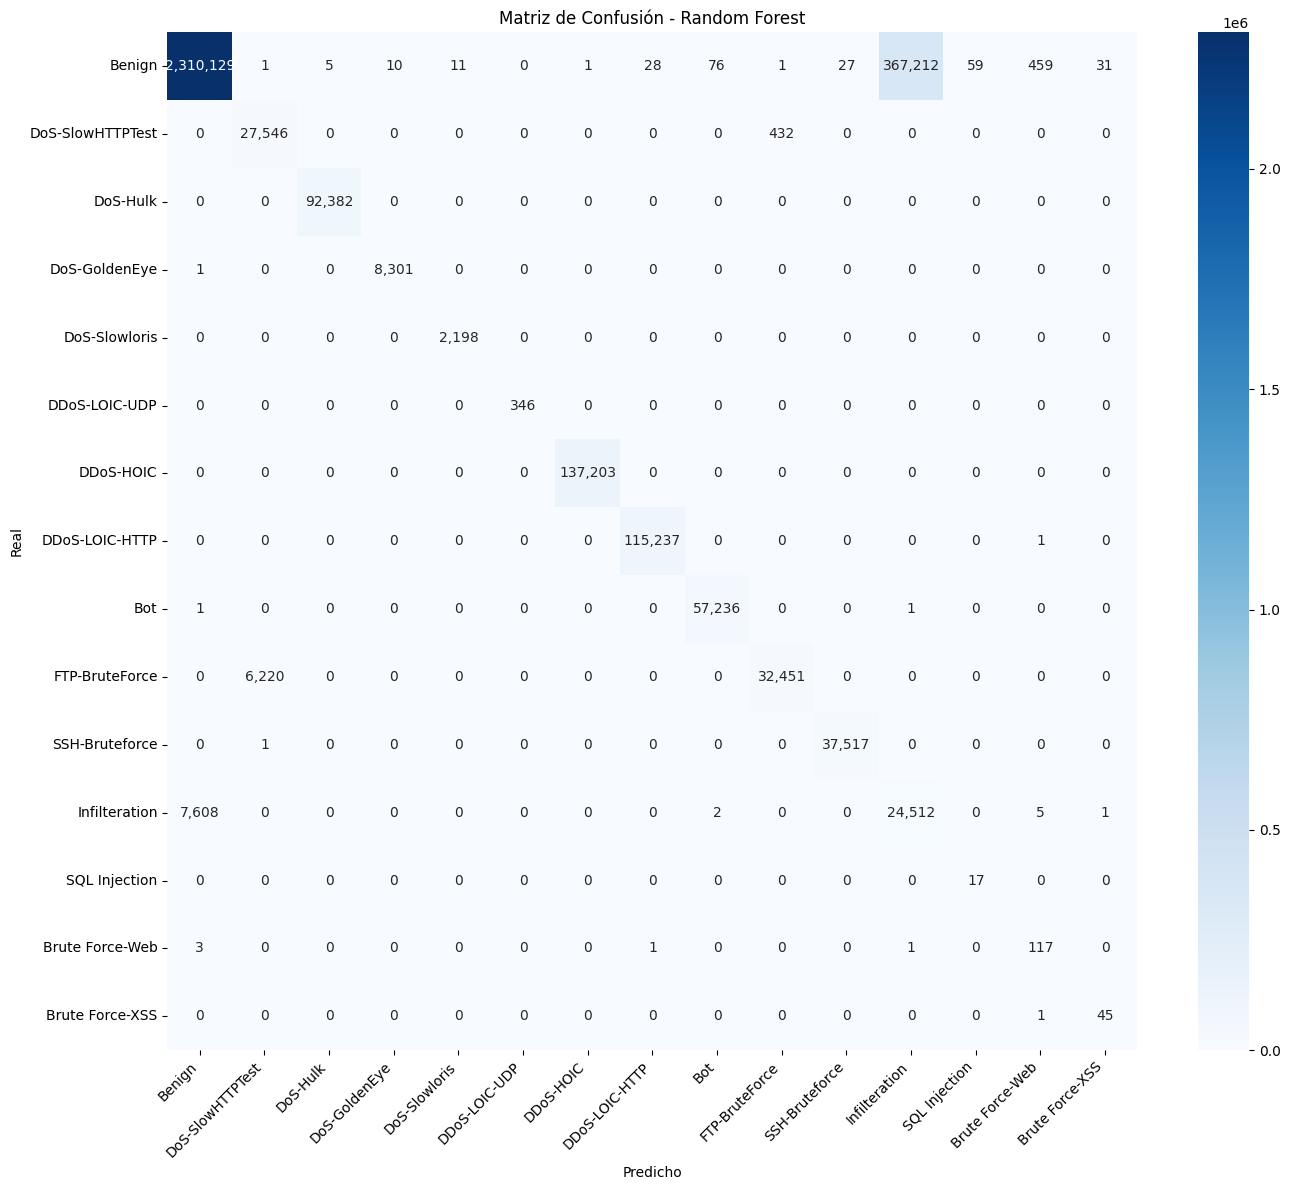

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'rf_confusion_matrix.png'), dpi=150)
plt.show()

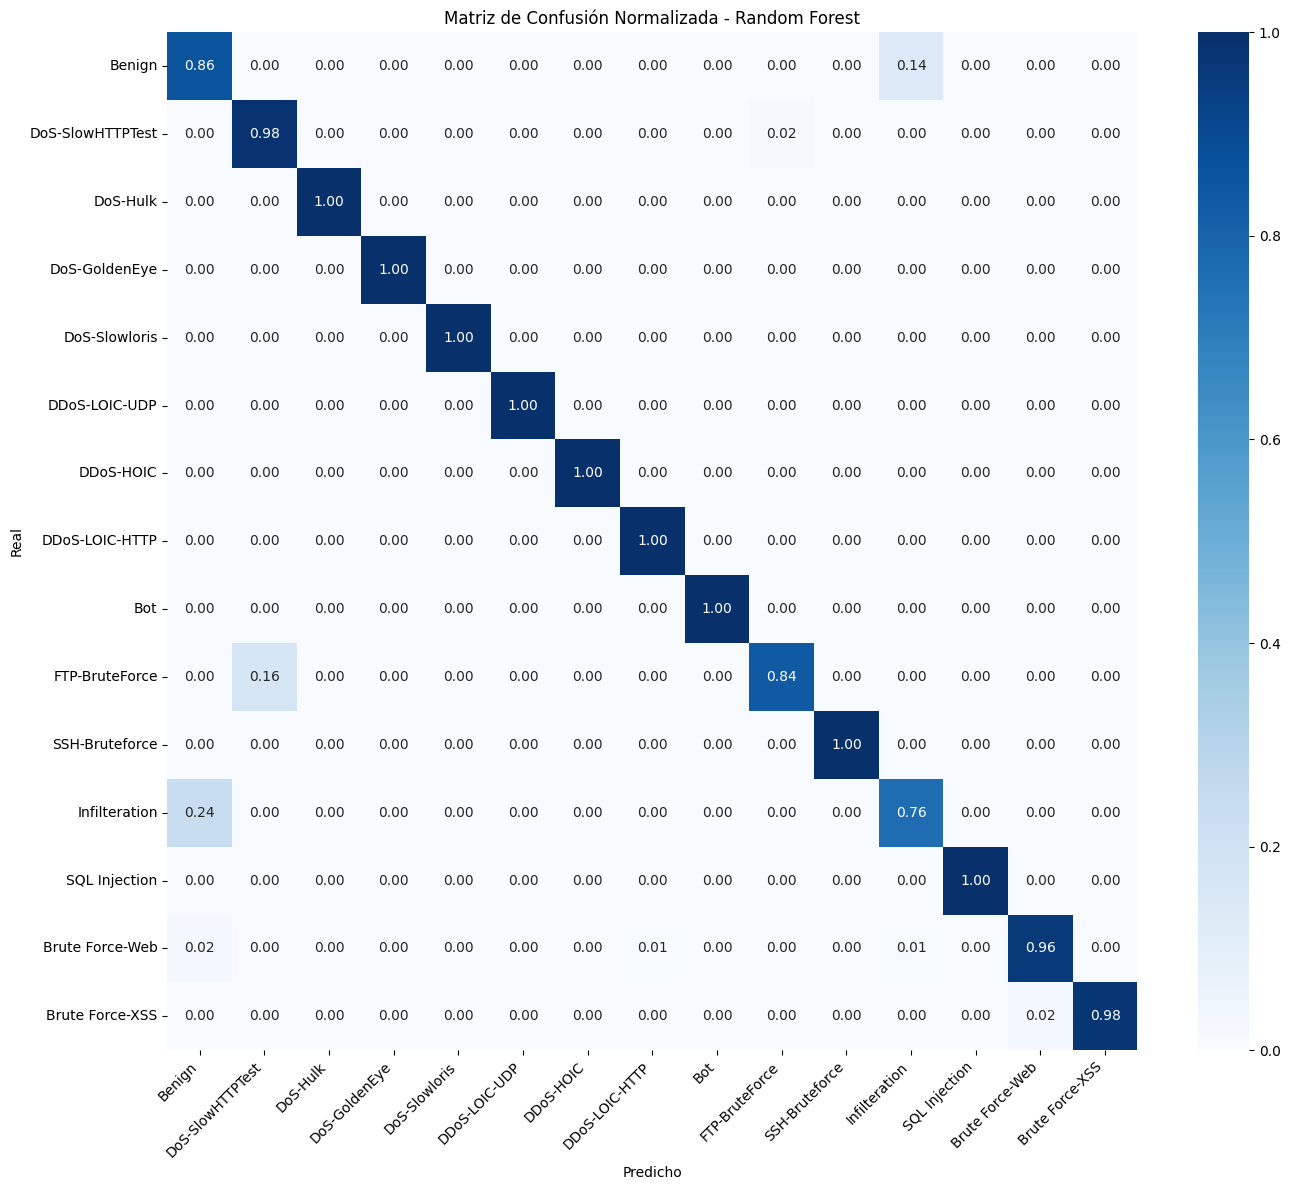

In [ ]:
# Matriz de confusión normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Normalizada - Random Forest')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'rf_confusion_matrix_normalized.png'), dpi=150)
plt.show()

## 6️⃣ Importancia de Features

In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("📊 Importancia de Features:")
print(feature_importance.to_string(index=False))

📊 Importancia de Features:
          feature  importance
Init Fwd Win Byts    0.172043
         Dst Port    0.144244
       Fwd Pkts/s    0.110189
 Fwd Seg Size Min    0.094027
              xhr    0.093782
       Bwd Pkts/s    0.073306
Init Bwd Win Byts    0.058022
  Fwd Pkt Len Max    0.042181
 Fwd Pkt Len Mean    0.041462
 Bwd Pkt Len Mean    0.034952
      Bwd IAT Max    0.018934
         Idle Min    0.018722
     ACK Flag Cnt    0.017657
      Bwd IAT Tot    0.016710
     Bwd IAT Mean    0.015428
     PSH Flag Cnt    0.011309
     RST Flag Cnt    0.010935
  Fwd Pkt Len Min    0.008076
       Protocol_6    0.007629
  Bwd Pkt Len Min    0.004129
      Protocol_17    0.003862
    Fwd PSH Flags    0.002402


/tmp/ipython-input-3714848561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


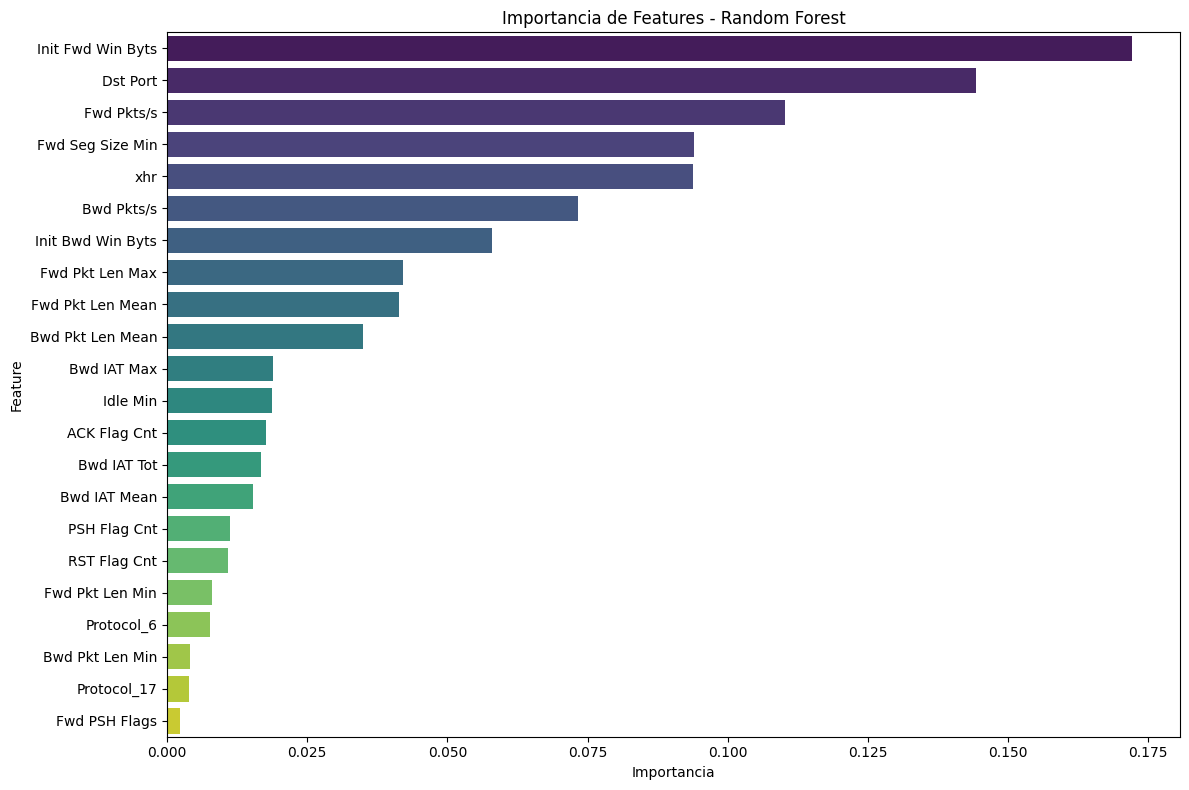

In [ ]:
# Visualizar importancia
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.title('Importancia de Features - Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'rf_feature_importance.png'), dpi=150)
plt.show()

## 7️⃣ Guardar modelo y artefactos

In [ ]:
# Guardar modelo
model_path = os.path.join(MODEL_DIR, 'random_forest_final.pkl')
joblib.dump(rf_best, model_path)
print(f"✅ Modelo guardado: {model_path}")

✅ Modelo guardado: /content/drive/MyDrive/data_ml1/models/random_forest_final.pkl


In [ ]:
# Guardar configuración y métricas
rf_config = {
    'best_params': grid_search.best_params_,
    'features': FEATURES,
    'n_classes': 15,
    'class_names': CLASS_NAMES,
    'metrics': {
        'accuracy': float(accuracy),
        'precision_weighted': float(precision),
        'recall_weighted': float(recall),
        'f1_macro': float(f1_macro),
        'f1_weighted': float(f1_weighted)
    }
}

config_path = os.path.join(MODEL_DIR, 'random_forest_config.pkl')
joblib.dump(rf_config, config_path)
print(f"✅ Configuración guardada: {config_path}")

✅ Configuración guardada: /content/drive/MyDrive/data_ml1/models/random_forest_config.pkl


In [ ]:
# Guardar predicciones para modelo híbrido
rf_predictions = pd.DataFrame({
    'prediction': y_pred,
    'true_label': y_test
})

# Añadir probabilidades por clase
for i in range(15):
    rf_predictions[f'prob_class_{i}'] = y_pred_proba[:, i]

pred_path = os.path.join(MODEL_DIR, 'rf_test_predictions.csv')
rf_predictions.to_csv(pred_path, index=False)
print(f"✅ Predicciones guardadas: {pred_path}")

✅ Predicciones guardadas: /content/drive/MyDrive/data_ml1/models/rf_test_predictions.csv


## 8️⃣ Resumen final

In [ ]:
print("="*70)
print("   🌲 RESUMEN - RANDOM FOREST PARA SIGNATURE DETECTION")
print("="*70)

print(f"\n⚙️ MEJORES HIPERPARÁMETROS:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 MÉTRICAS FINALES:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1-Score (macro): {f1_macro:.4f}")
print(f"   F1-Score (weighted): {f1_weighted:.4f}")

print(f"\n🔝 TOP 5 FEATURES MÁS IMPORTANTES:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

print(f"\n📁 ARCHIVOS GUARDADOS:")
print(f"   • random_forest_final.pkl")
print(f"   • random_forest_config.pkl")
print(f"   • rf_test_predictions.csv")

print(f"\n📍 UBICACIÓN: {MODEL_DIR}")
print("\n" + "="*70)
print("   ✅ ¡RANDOM FOREST ENTRENADO EXITOSAMENTE!")
print("="*70)

   🌲 RESUMEN - RANDOM FOREST PARA SIGNATURE DETECTION

⚙️ MEJORES HIPERPARÁMETROS:
   max_depth: 30
   max_features: sqrt
   min_samples_leaf: 2
   min_samples_split: 5
   n_estimators: 200

📊 MÉTRICAS FINALES:
   Accuracy: 0.8816
   Precision: 0.9861
   Recall: 0.8816
   F1-Score (macro): 0.8176
   F1-Score (weighted): 0.9267

🔝 TOP 5 FEATURES MÁS IMPORTANTES:
   Init Fwd Win Byts: 0.1720
   Dst Port: 0.1442
   Fwd Pkts/s: 0.1102
   Fwd Seg Size Min: 0.0940
   xhr: 0.0938

📁 ARCHIVOS GUARDADOS:
   • random_forest_final.pkl
   • random_forest_config.pkl
   • rf_test_predictions.csv

📍 UBICACIÓN: /content/drive/MyDrive/data_ml1/models

   ✅ ¡RANDOM FOREST ENTRENADO EXITOSAMENTE!


---

## ✅ ¡Random Forest completado!

### Archivos generados:
| Archivo | Descripción |
|---------|-------------|
| `random_forest_final.pkl` | Modelo entrenado |
| `random_forest_config.pkl` | Hiperparámetros y métricas |
| `rf_test_predictions.csv` | Predicciones para modelo híbrido |

### Siguiente paso:
- Entrenar **Deep Neural Network (DNN)**